# Pipeline Comparison: Custom RAG vs LlamaIndex

This notebook sends the same questions to both pipelines and compares:
- Answer quality
- Retrieved chunks and scores
- Response time

In [1]:
import sys
import time
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

sys.path.append("..")

from src.rag.pipeline import RAGPipeline
from src.llamaindex.pipeline import LlamaIndexPipeline

print("Loading pipelines...")
custom_pipeline = RAGPipeline(data_dir="../data")
llama_pipeline = LlamaIndexPipeline(data_dir="../data")
print("Pipelines ready.")

/opt/anaconda3/envs/rag-mlops/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/opt/anaconda3/envs/rag-mlops/lib/python3.11/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


Loading pipelines...


Loading weights: 100%|██████████████████████| 103/103 [00:00<00:00, 9294.41it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading model from /Users/jieyu/PycharmProjects/rag-mlops/models/reranker


Loading weights: 100%|██████████████████████| 105/105 [00:00<00:00, 7049.81it/s]


Index loaded from indexes/faiss.index with 51 vectors
Index loaded from disk, skipping rebuild


Loading weights: 100%|██████████████████████| 103/103 [00:00<00:00, 4784.89it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


LlamaIndex: indexing 'methodology_fixed.docx'...
LlamaIndex: indexing 'Team1_Comp Anlys of UAV Position Pred Models (1).docx'...
LlamaIndex: indexing 'implementation_short.docx'...
LlamaIndex: indexing '11OSproject.docx'...
LlamaIndex: indexing 'implementation_v2.docx'...
LlamaIndex: indexed 51 chunks from 5 file(s).


2026-04-05 19:55:02,983 - INFO - HTTP Request: POST http://localhost:11434/api/show "HTTP/1.1 200 OK"


Pipelines ready.


In [3]:
# Define test questions
TEST_QUESTIONS = [
    "What is virtual memory?",
    "How does process scheduling work?",
    "What is a deadlock and how can it be prevented?",
    "Explain the difference between threads and processes.",
    "What is a semaphore?",
]

In [5]:
def run_pipeline(pipeline, questions):
    results = []
    for q in questions:
        start = time.time()
        result = pipeline.query(q)
        elapsed = time.time() - start
        results.append({
            "question": q,
            "answer": result["answer"],
            "chunks": result["retrieved_chunks"],
            "response_time": round(elapsed, 2),
            "top_score": result["retrieved_chunks"][0]["score"] if result["retrieved_chunks"] else 0,
        })
        print(f"  ✓ '{q[:40]}...' ({elapsed:.1f}s)")
    return results

print("Running custom pipeline...")
custom_results = run_pipeline(custom_pipeline, TEST_QUESTIONS)

print("\nRunning LlamaIndex pipeline...")
llama_results = run_pipeline(llama_pipeline, TEST_QUESTIONS)

Running custom pipeline...


Batches: 100%|████████████████████████████████████| 1/1 [00:00<00:00, 19.71it/s]
2026-04-05 19:55:50,525 - INFO - HTTP Request: POST http://127.0.0.1:11434/api/chat "HTTP/1.1 200 OK"


  ✓ 'What is virtual memory?...' (8.5s)


Batches: 100%|████████████████████████████████████| 1/1 [00:00<00:00, 63.42it/s]
2026-04-05 19:56:02,645 - INFO - HTTP Request: POST http://127.0.0.1:11434/api/chat "HTTP/1.1 200 OK"


  ✓ 'How does process scheduling work?...' (12.1s)


...

  ✓ 'What is a deadlock and how can it be pre...' (41.4s)


2026-04-05 19:59:10,981 - INFO - HTTP Request: POST http://localhost:11434/api/chat "HTTP/1.1 200 OK"


  ✓ 'Explain the difference between threads a...' (37.7s)


2026-04-05 19:59:55,522 - INFO - HTTP Request: POST http://localhost:11434/api/chat "HTTP/1.1 200 OK"


  ✓ 'What is a semaphore?...' (44.5s)


In [7]:
# Side-by-side answer comparison
for i, q in enumerate(TEST_QUESTIONS):
    print(f"{'='*70}")
    print(f"Q: {q}")
    print(f"{'─'*70}")
    print(f"[Custom RAG]\n{custom_results[i]['answer'][:300]}...")
    print(f"{'─'*70}")
    print(f"[LlamaIndex]\n{llama_results[i]['answer'][:300]}...")
    print()

Q: What is virtual memory?
──────────────────────────────────────────────────────────────────────
[Custom RAG]
I don't know based on the provided document....
──────────────────────────────────────────────────────────────────────
[LlamaIndex]
I don't know based on the provided document....

Q: How does process scheduling work?
──────────────────────────────────────────────────────────────────────
[Custom RAG]
I don't know based on the provided document. The context only discusses task scheduling in FreeRTOS and VxWorks, not process scheduling....
──────────────────────────────────────────────────────────────────────
[LlamaIndex]
I don't know based on the provided document, because the term "process" is not mentioned in it. The text only discusses task scheduling for real-time operating systems (RTOS) like FreeRTOS and VxWorks....

Q: What is a deadlock and how can it be prevented?
──────────────────────────────────────────────────────────────────────
[Custom RAG]
I don't know based on 

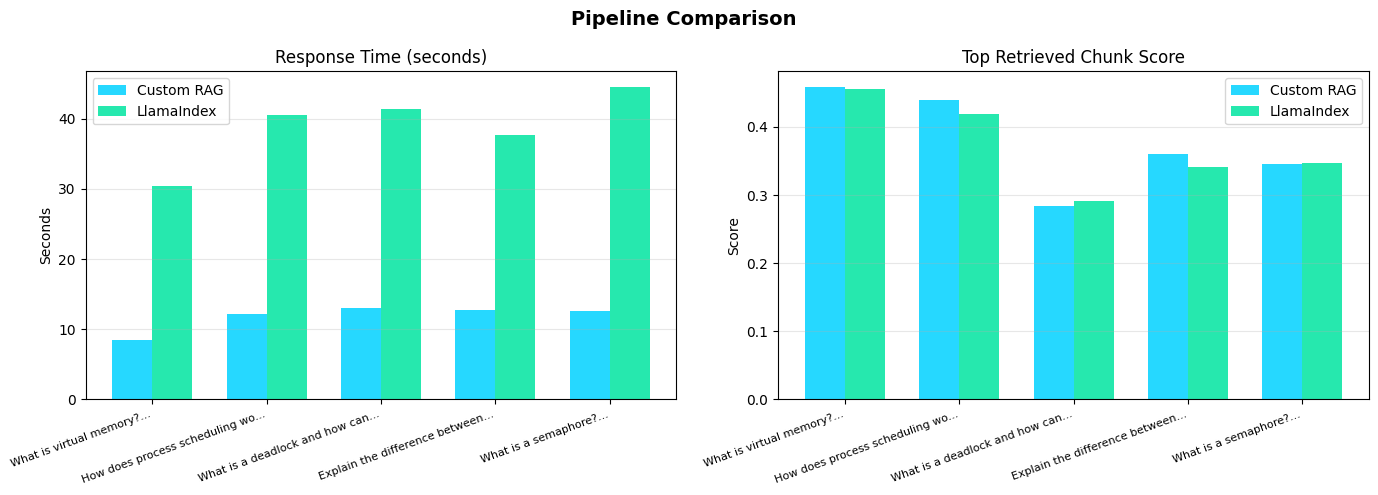

In [9]:
# Response time comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Pipeline Comparison", fontsize=14, fontweight="bold")

short_questions = [q[:30] + "..." for q in TEST_QUESTIONS]
custom_times = [r["response_time"] for r in custom_results]
llama_times = [r["response_time"] for r in llama_results]

x = range(len(TEST_QUESTIONS))
width = 0.35

# Response time bar chart
axes[0].bar([i - width/2 for i in x], custom_times, width, label="Custom RAG", color="#00d2ff", alpha=0.85)
axes[0].bar([i + width/2 for i in x], llama_times, width, label="LlamaIndex", color="#00e5a0", alpha=0.85)
axes[0].set_title("Response Time (seconds)")
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(short_questions, rotation=20, ha="right", fontsize=8)
axes[0].set_ylabel("Seconds")
axes[0].legend()
axes[0].grid(axis="y", alpha=0.3)

# Top chunk score comparison
custom_scores = [r["top_score"] for r in custom_results]
llama_scores = [r["top_score"] for r in llama_results]

axes[1].bar([i - width/2 for i in x], custom_scores, width, label="Custom RAG", color="#00d2ff", alpha=0.85)
axes[1].bar([i + width/2 for i in x], llama_scores, width, label="LlamaIndex", color="#00e5a0", alpha=0.85)
axes[1].set_title("Top Retrieved Chunk Score")
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(short_questions, rotation=20, ha="right", fontsize=8)
axes[1].set_ylabel("Score")
axes[1].legend()
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("pipeline_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

In [11]:
# Summary table
summary = pd.DataFrame({
    "Question": TEST_QUESTIONS,
    "Custom Time (s)": custom_times,
    "LlamaIndex Time (s)": llama_times,
    "Custom Top Score": [round(s, 3) for s in custom_scores],
    "LlamaIndex Top Score": [round(s, 3) for s in llama_scores],
})

print("=== Summary ===")
print(f"Avg response time — Custom: {sum(custom_times)/len(custom_times):.2f}s | LlamaIndex: {sum(llama_times)/len(llama_times):.2f}s")
print(f"Avg top score    — Custom: {sum(custom_scores)/len(custom_scores):.3f} | LlamaIndex: {sum(llama_scores)/len(llama_scores):.3f}")
print()
summary

=== Summary ===
Avg response time — Custom: 11.78s | LlamaIndex: 38.92s
Avg top score    — Custom: 0.378 | LlamaIndex: 0.371



,Question,Custom Time (s),LlamaIndex Time (s),Custom Top Score,LlamaIndex Top Score
0,What is virtual memory?,8.50,30.42,0.459,0.455
1,How does process scheduling work?,12.12,40.52,0.439,0.418
2,What is a deadlock and how can it be prevented?,13.00,41.40,0.284,0.291
3,Explain the difference between threads and pro...,12.73,37.70,0.360,0.342
4,What is a semaphore?,12.56,44.54,0.346,0.348
